In [1]:
import sleap
import sys
import cmath

sys.path.append('..')
from python.polygon_based_correction import *
from eval.eval import *

In [2]:
corrected_points_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/manual_5min_c0_tracked_points.npy'
corrected_points = np.load(corrected_points_path)
print(corrected_points.shape)

(9000, 17, 2)


total_range_length: 4264


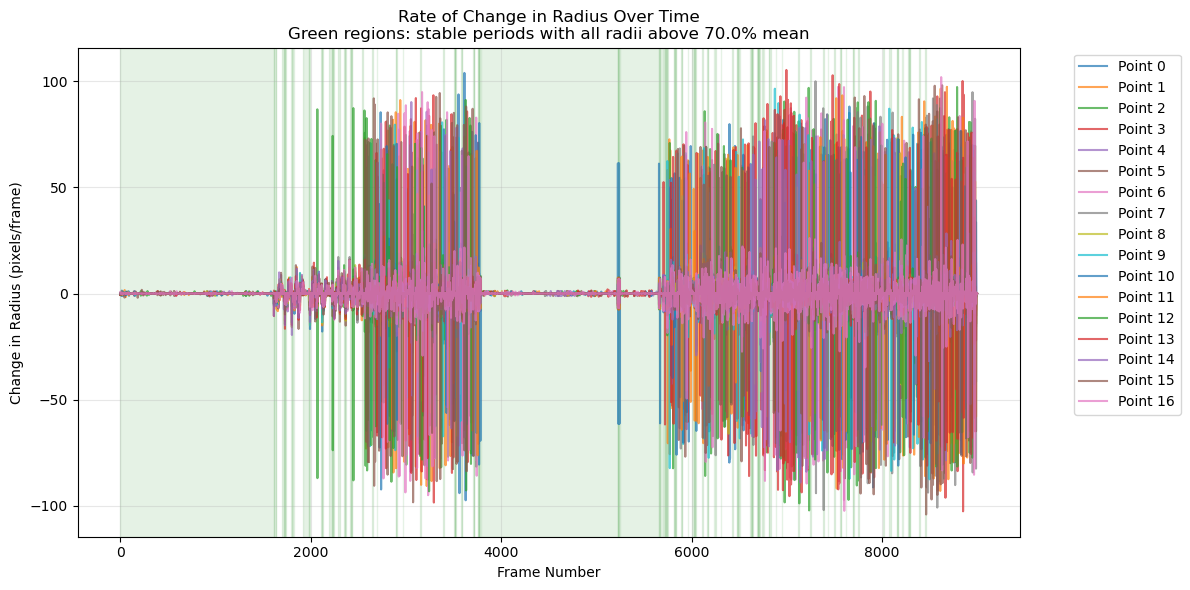

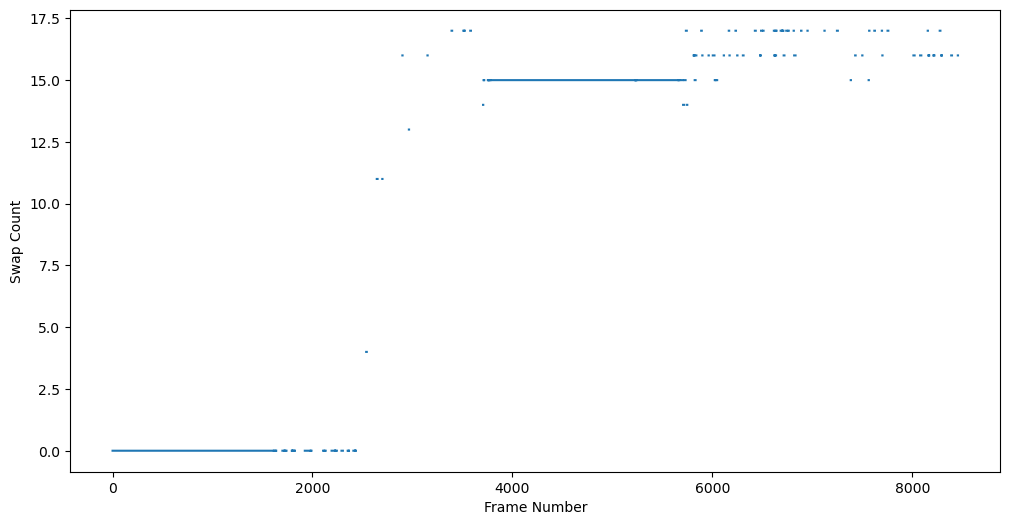

In [29]:
eval_dataset_from_points(corrected_points, method='polygon');

In [3]:
poly_4_correction = polygon_correction_with_points(corrected_points, poly_4)
eval_dataset_from_points(poly_4_correction, method='polygon', count_missing=True);

TypeError: eval_dataset_from_points() got an unexpected keyword argument 'count_missing'

total_range_length: 5108


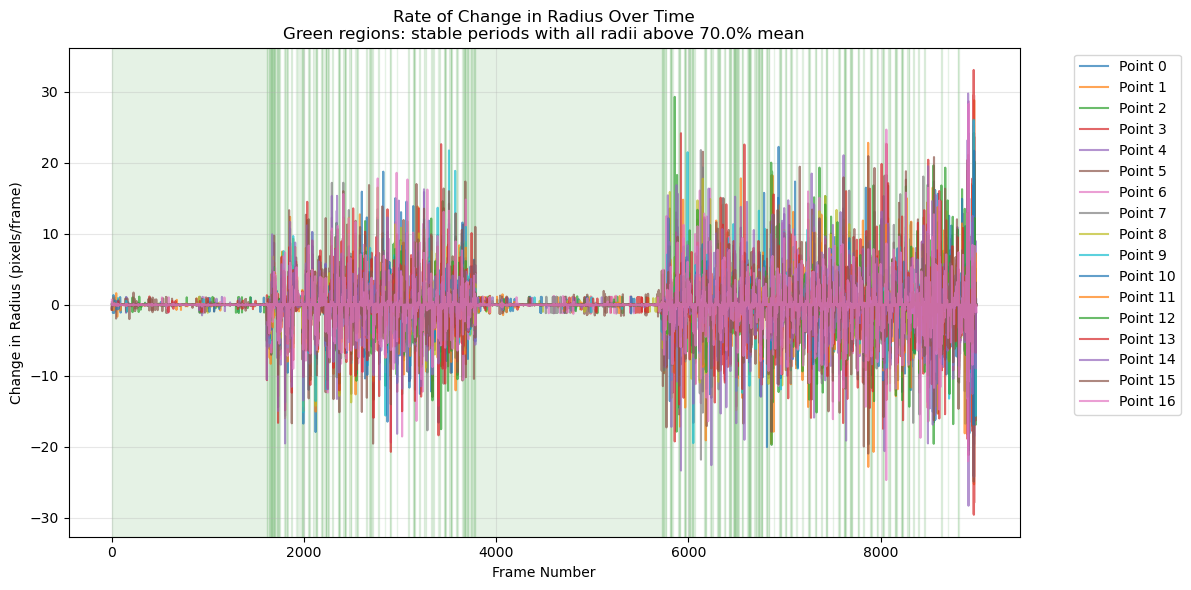

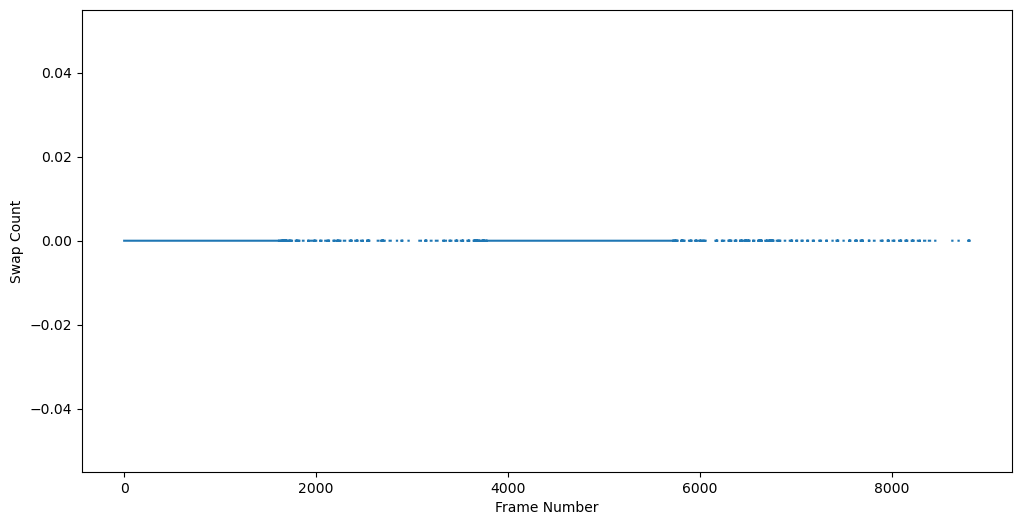

In [30]:
poly_4_correction = polygon_correction_with_points(corrected_points, poly_4)
eval_dataset_from_points(poly_4_correction, method='polygon');

total_range_length: 2433


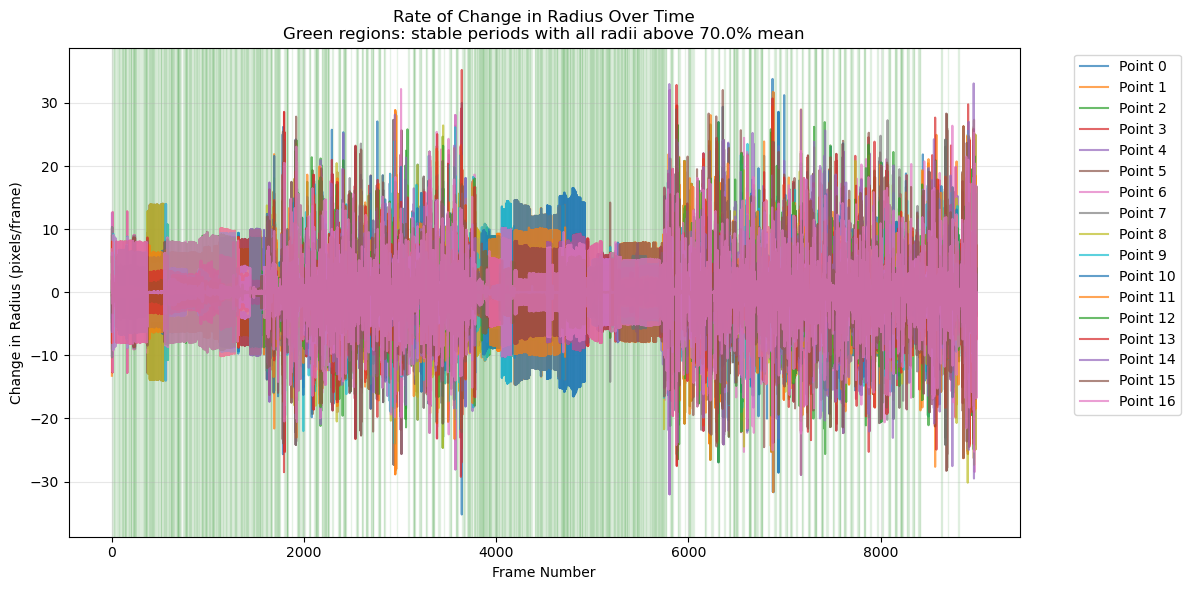

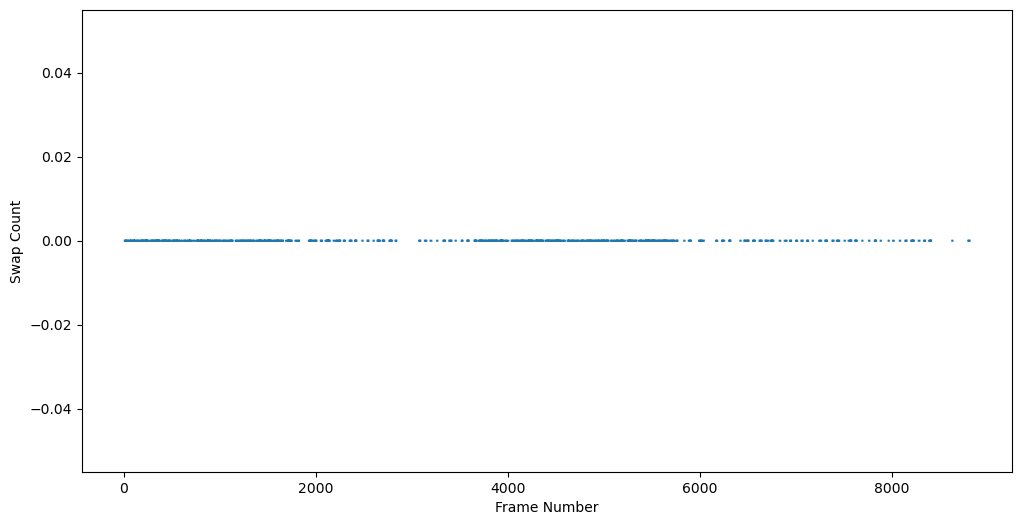

In [32]:
poly_3_correction = polygon_correction_with_points(corrected_points, poly_3)
eval_dataset_from_points(poly_3_correction, method='polygon');

In [15]:
c0_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/manual_5min_c0.slp'
c0_dataset = sleap.load_file(c0_dataset_path)
print(c0_dataset)

Labels(labeled_frames=9000, videos=1, skeletons=1, tracks=17)


In [30]:
poly_3_correction, id_mappings_3 = polygon_correction_with_points(corrected_points, poly_3, return_indices=True)
poly_4_correction, id_mappings_4 = polygon_correction_with_points(corrected_points, poly_4, return_indices=True)

In [44]:
results_dir = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/'
poly_3_corrected_dataset = dataset_with_new_points(c0_dataset, poly_3_correction, handle_first_frame=False, node_name='tb')
poly_4_corrected_dataset = dataset_with_new_points(c0_dataset, poly_4_correction, handle_first_frame=False, node_name='tb')
poly_3_corrected_dataset.save(results_dir + 'poly_3_corrected_c0.slp')
poly_4_corrected_dataset.save(results_dir + 'poly_4_corrected_c0.slp')

missing_pt_cnt: 7440
missing_pt_cnt: 7440


In [45]:
poly_diff = (np.abs(id_mappings_3 - id_mappings_4) > 1).sum(axis=(1,))
print(poly_diff.shape)
print(len(poly_diff[poly_diff > 0]))

(9000,)

In [46]:
len(poly_diff[poly_diff > 0])

8827

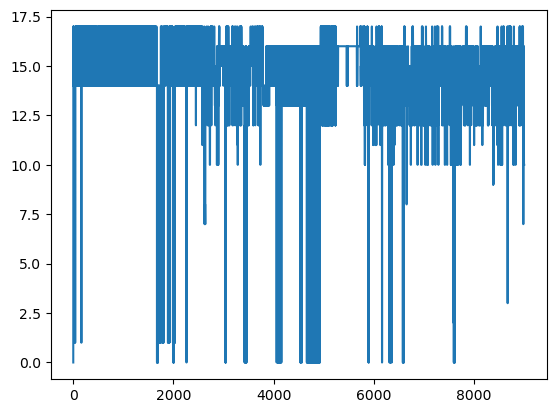

In [47]:
plt.plot(poly_diff);

In [36]:
frame_idx = 1000
print(id_mappings_3[frame_idx])
print(id_mappings_4[frame_idx])


[10  9  8  7  6  5  4  3  2  1  0 16 15 14 13 12 11]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


In [42]:
frame_idx = 4
print(id_mappings_3[frame_idx])
print(id_mappings_4[frame_idx])

[ 5  4  3  2  1  0 16 15 14 13 12 11 10  9  8  7  6]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


In [12]:
arr = np.array([[0, 0], [1, 2], [3, 4], [5, 6], [0, 0]])
arr.sum(axis=1) > 0

array([False,  True,  True,  True, False])

In [13]:
np.where(arr)

array([[1, 2],
       [3, 4],
       [5, 6],
       [0, 0],
       [0, 0]])

In [7]:
((arr - (1, 1) )**2).sum(axis=1)


array([ 1, 13, 41,  2])

In [46]:
# adapted from https://stackoverflow.com/questions/20924085/python-conversion-between-coordinates

def cart2pol(xy_arr, center_pos=(0, 0)):
    xy_arr = xy_arr - center_pos
    x = xy_arr[:, 0]
    y = xy_arr[:, 1]
    rho = np.hypot(x, y)
    phi = np.arctan2(y, x)
    return np.array([rho, phi]).T

def pol2cart(rho_phi_arr, center_pos=(0, 0)):
    rho = rho_phi_arr[:, 0]
    phi = rho_phi_arr[:, 1]
    x = rho * np.cos(phi)
    y = rho * np.sin(phi)
    return np.array([x, y]).T + center_pos

In [33]:
def cart2pol(xy_arr, center_pos=(0, 0)):
    xy_arr = xy_arr - center_pos
    x = xy_arr[:, 0]
    y = xy_arr[:, 1]
    rho = np.hypot(x, y)  # hypot always returns non-negative values
    phi = np.arctan2(y, x)
    # Convert phi from [-π, π] to [0, 2π] range
    phi = -phi + np.pi
    return np.array([rho, phi]).T

def pol2cart(rho_phi_arr, center_pos=(0, 0)):
    rho = np.abs(rho_phi_arr[:, 0])  # Ensure rho is positive
    phi = np.mod(rho_phi_arr[:, 1], 2*np.pi)  # Ensure phi is in [0, 2π]
    x = rho * np.cos(phi)
    y = rho * np.sin(phi)
    return np.array([x, y]).T + center_pos

In [34]:
coords = np.array([[1, 2], [3, 4], [5, 6], [0, 0]])
pol_coords = cart2pol(coords)
print(pol_coords.shape)
print(pol_coords)
cart_coords = pol2cart(pol_coords)
print(cart_coords.shape)
print(cart_coords)

(4, 2)
[[2.23606798 2.03444394]
 [5.         2.21429744]
 [7.81024968 2.2655346 ]
 [0.         3.14159265]]
(4, 2)
[[-1.  2.]
 [-3.  4.]
 [-5.  6.]
 [ 0.  0.]]


In [35]:
coords.mean(axis=0)

array([2.25, 3.  ])

In [36]:
def polar_interpolate(curr_frame_pts, non_missing_mask=None):
    if non_missing_mask is None:
        non_missing_mask = curr_frame_pts.sum(axis=1) > 0
    non_missing_pts = curr_frame_pts[non_missing_mask]
    center_pos = non_missing_pts.mean(axis=0)
    polar_coords = cart2pol(curr_frame_pts, center_pos)
    for pt_idx in range(len(curr_frame_pts)):
        if not non_missing_mask[pt_idx]:
            continue
    

In [44]:
def deg2rad(deg):
    return deg * np.pi / 180

def rad2deg(rad):
    return rad * 180 / np.pi

def polar_interpolate(curr_frame_pts, non_missing_mask=None, center_pos=None):
    
    if non_missing_mask is None:
        non_missing_mask = ~(curr_frame_pts == 0).all(axis=1)
    
    first_non_missing_idx = np.where(non_missing_mask)[0][0]
    curr_frame_pts = np.roll(curr_frame_pts, -first_non_missing_idx, axis=0)
    non_missing_mask = np.roll(non_missing_mask, -first_non_missing_idx, axis=0)
    non_missing_indices = np.where(non_missing_mask)[0]
    
    if center_pos is None:
        center_pos = curr_frame_pts[non_missing_mask].mean(axis=0)
    
    polar_coords = cart2pol(curr_frame_pts, center_pos)
    cart_interpolated_pts = np.zeros_like(curr_frame_pts)
    pt_cnt = len(curr_frame_pts)
    
    for pt_idx in range(pt_cnt):
        if non_missing_mask[pt_idx]:
            continue
            
        prev_idx = non_missing_indices[non_missing_indices < pt_idx][-1] if any(non_missing_indices < pt_idx) else non_missing_indices[-1]
        next_idx = non_missing_indices[non_missing_indices > pt_idx][0] if any(non_missing_indices > pt_idx) else non_missing_indices[0]
        
        if next_idx > prev_idx:
            denom = next_idx - prev_idx
        else:
            denom = pt_cnt - (prev_idx - next_idx)
        weight = ((pt_idx - prev_idx) % pt_cnt) / denom
        r1, theta1 = polar_coords[prev_idx]
        r2, theta2 = polar_coords[next_idx]

        r_interp = r1 + abs(weight) * (r2 - r1)
        if theta1 > theta2:
            theta2 += 2*np.pi
        theta_interp = np.mod(theta1 + weight * (theta2 - theta1), 2*np.pi)
        
        cart_interpolated_pts[pt_idx] = pol2cart(np.array([[r_interp, theta_interp]]), center_pos)[0]

    cart_interpolated_pts = np.roll(cart_interpolated_pts, first_non_missing_idx, axis=0)
    return cart_interpolated_pts

In [43]:
polar_arr = np.array([[0, 0], [2, 90], [0, 0], [2, 270]], dtype=np.float64)
# polar_arr = np.array([[0, 0], [2, 90], [0, 0], [4, 270]])
polar_arr[:, 1] = deg2rad(polar_arr[:, 1])
# print(polar_arr)
cart_arr = pol2cart(polar_arr)
# print(np.round(cart_arr, 2))
cart_arr_interpolated = polar_interpolate(cart_arr, center_pos=(0, 0))
polar_arr_interpolated = cart2pol(cart_arr_interpolated)
polar_arr_interpolated[:, 1] = rad2deg(polar_arr_interpolated[:, 1])
print(polar_arr_interpolated)
print(np.round(cart_arr_interpolated, 2))

polar_coords: 
[[2.         1.57079633]
 [0.         3.14159265]
 [2.         4.71238898]
 [0.         3.14159265]]
non_missing_indices: 
[0 2]
prev_idx: 0, next_idx: 2, weight: 0.5
prev_idx: 2, next_idx: 0, weight: 0.5
polar_interpolated_pts: 
[[2.         1.57079633]
 [2.         3.14159265]
 [2.         4.71238898]
 [2.         0.        ]]
[[  2. 180.]
 [  2.  90.]
 [  2.   0.]
 [  2. 270.]]
[[ 2.  0.]
 [ 0.  2.]
 [-2.  0.]
 [-0. -2.]]


In [45]:
def assign_id_to_points(all_tracked_points, frame_idx, polygon_constructor=poly_3):
    curr_frame_pts = all_tracked_points[frame_idx].copy()
    pt_cnt = len(curr_frame_pts)
    non_missing_mask = curr_frame_pts.sum(axis=1) > 0 # 1 = non-missing, 0 = missing
    
    # if non_missing_mask.sum() == pt_cnt:
    #     assign_id_to_points_non_missing(all_tracked_points, frame_idx, polygon_constructor)
    #     return
    
    curr_id_mapping = [None for _ in range(pt_cnt)]
    prev_frame_pts = all_tracked_points[frame_idx-1]
    
    # for non-missing points, assign id based on nearest neighbor in previous frame
    matching_queue = [] # (dist, pt_idx, sorted_idx)
    updated_non_missing_mask = np.zeros_like(non_missing_mask)
    for pt_idx in range(len(curr_frame_pts)):
        if not non_missing_mask[pt_idx]:
            continue
        dists = ((curr_frame_pts[pt_idx] - prev_frame_pts)**2).sum(axis=1)
        dists_sorted_idx = np.argmin(dists)
        # if the closest neighbor is too far away, this point may be mispredicted?
        matching_queue.append((dists[dists_sorted_idx], pt_idx, dists_sorted_idx))
    
    matching_queue.sort(key=lambda x: x[0])
    
    for _, pt_idx, sorted_idx in matching_queue:
        if sorted_idx not in curr_id_mapping:
            curr_id_mapping[pt_idx] = sorted_idx
            all_tracked_points[frame_idx][sorted_idx] = curr_frame_pts[pt_idx]
            updated_non_missing_mask[pt_idx] = 1
    
    # for missing points, interpolate from its two neighbors using polar coordinates
    polar_interpolated_pts = polar_interpolate(all_tracked_points[frame_idx], updated_non_missing_mask)
    for pt_idx in range(pt_cnt):
        if pt_idx in curr_id_mapping:
            continue
        all_tracked_points[frame_idx][pt_idx] = polar_interpolated_pts[pt_idx]
    
    # assign order again to ensure maximal global alignment
    assign_id_to_points_non_missing(all_tracked_points, frame_idx, polygon_constructor)
        
def assign_id_to_points_non_missing(all_tracked_points, frame_idx, polygon_constructor=poly_3):
    curr_frame_pts = all_tracked_points[frame_idx]
    polygon_order = polygon_constructor(curr_frame_pts)
    best_shift = find_best_roll(curr_frame_pts[polygon_order], all_tracked_points[frame_idx-1])
    shifted_indices = np.roll(polygon_order, best_shift, axis=0)
    all_tracked_points[frame_idx] = curr_frame_pts[shifted_indices]

def polygon_correction_with_points(all_tracked_points, polygon_constructor=poly_3, return_indices=False):

    frame_cnt = all_tracked_points.shape[0]
    corrected_coords = all_tracked_points.copy()

    for frame_idx in range(1, frame_cnt):
        assign_id_to_points(corrected_coords, frame_idx, polygon_constructor)

    return corrected_coords

In [13]:
poly_3_correction_v3 = polygon_correction_with_points(corrected_points, poly_3, return_indices=True)
poly_4_correction_v3 = polygon_correction_with_points(corrected_points, poly_4, return_indices=True)

In [16]:
results_dir = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/'
poly_3_corrected_dataset_v3 = dataset_with_new_points(c0_dataset, poly_3_correction_v3, handle_first_frame=False, node_name='tb')
poly_4_corrected_dataset_v3 = dataset_with_new_points(c0_dataset, poly_4_correction_v3, handle_first_frame=False, node_name='tb')
poly_3_corrected_dataset_v3.save(results_dir + 'poly_3_corrected_c0_v3.slp')
poly_4_corrected_dataset_v3.save(results_dir + 'poly_4_corrected_c0_v3.slp')

missing_pt_cnt: 0
missing_pt_cnt: 0


In [23]:
poly_diff = (np.abs(poly_3_correction_v3 - poly_4_correction_v3) > 20).sum(axis=(1,2))
print(poly_diff.shape)
print(len(poly_diff[poly_diff > 0]))

(9000,)
8514


In [25]:
poly_3_correction_v4 = polygon_correction_with_points(corrected_points, poly_3, return_indices=True)
poly_4_correction_v4 = polygon_correction_with_points(corrected_points, poly_4, return_indices=True)

In [26]:
results_dir = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/'
poly_3_corrected_dataset_v4 = dataset_with_new_points(c0_dataset, poly_3_correction_v4, handle_first_frame=False, node_name='tb')
poly_4_corrected_dataset_v4 = dataset_with_new_points(c0_dataset, poly_4_correction_v4, handle_first_frame=False, node_name='tb')
poly_3_corrected_dataset_v4.save(results_dir + 'poly_3_corrected_c0_v4.slp')
poly_4_corrected_dataset_v4.save(results_dir + 'poly_4_corrected_c0_v4.slp')

missing_pt_cnt: 0
missing_pt_cnt: 0


In [27]:
poly_3_correction_v5 = polygon_correction_with_points(corrected_points, poly_3, return_indices=True)
poly_4_correction_v5 = polygon_correction_with_points(corrected_points, poly_4, return_indices=True)

In [28]:
results_dir = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/'
poly_3_corrected_dataset_v5 = dataset_with_new_points(c0_dataset, poly_3_correction_v5, handle_first_frame=False, node_name='tb')
poly_4_corrected_dataset_v5 = dataset_with_new_points(c0_dataset, poly_4_correction_v5, handle_first_frame=False, node_name='tb')
poly_3_corrected_dataset_v5.save(results_dir + 'poly_3_corrected_c0_v5.slp')
poly_4_corrected_dataset_v5.save(results_dir + 'poly_4_corrected_c0_v5.slp')

missing_pt_cnt: 0
missing_pt_cnt: 0


In [34]:
poly_3_correction_v6 = polygon_correction_with_points(corrected_points, poly_3, return_indices=True)
poly_4_correction_v6 = polygon_correction_with_points(corrected_points, poly_4, return_indices=True)
results_dir = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/'
poly_3_corrected_dataset_v6 = dataset_with_new_points(c0_dataset, poly_3_correction_v6, handle_first_frame=False, node_name='tb')
poly_4_corrected_dataset_v6 = dataset_with_new_points(c0_dataset, poly_4_correction_v6, handle_first_frame=False, node_name='tb')
poly_3_corrected_dataset_v6.save(results_dir + 'poly_3_corrected_c0_v6.slp')
poly_4_corrected_dataset_v6.save(results_dir + 'poly_4_corrected_c0_v6.slp')

missing_pt_cnt: 0
missing_pt_cnt: 0


In [ ]:
poly_3_correction_v7 = polygon_correction_with_points(corrected_points, poly_3, return_indices=True)
poly_4_correction_v7 = polygon_correction_with_points(corrected_points, poly_4, return_indices=True)
results_dir = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/'
poly_3_corrected_dataset_v7 = dataset_with_new_points(c0_dataset, poly_3_correction_v7, handle_first_frame=False, node_name='tb')
poly_4_corrected_dataset_v7 = dataset_with_new_points(c0_dataset, poly_4_correction_v7, handle_first_frame=False, node_name='tb')
poly_3_corrected_dataset_v7.save(results_dir + 'poly_3_corrected_c0_v7.slp')
poly_4_corrected_dataset_v7.save(results_dir + 'poly_4_corrected_c0_v7.slp')